In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Ecommerce Customers.csv")

In [5]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [7]:
df['Yearly Amount Spent'].mean()

499.31403825859053

In [16]:
average = df['Yearly Amount Spent'].mean()
df['High_spender'] = (df['Yearly Amount Spent'] >= average).astype(int) ##astype used to convert true=1,false=0

In [15]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,High_spender
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054,1
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933,0
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505,0
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344,1
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092,1


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [25]:
## Data Splitting 
X = df[["Avg. Session Length",
        "Time on App",
        "Time on Website",
        "Length of Membership"]]

y = df['High_spender']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size =0.3)

In [45]:
X

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [27]:
## Model building
model = LogisticRegression()
model.fit(X_test,y_test)

LogisticRegression()

In [34]:
## Prediction
probabilities = model.predict_proba(X_test)[:, 1]

##convert to class
predicted_class = (probabilities > 0.5).astype(int)

In [35]:
# Show first 5 predictions
for i in range(5):
    print("Probability:", round(probabilities[i],2),
          "predicted:", predicted_class[i],
          "Actual:", y_test.values[i])

Probability: 0.97 predicted: 1 Actual: 1
Probability: 0.68 predicted: 1 Actual: 1
Probability: 0.09 predicted: 0 Actual: 0
Probability: 0.02 predicted: 0 Actual: 0
Probability: 0.0 predicted: 0 Actual: 0


In [36]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,High_spender
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054,1
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933,0
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505,0
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344,1
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092,1


In [43]:
## Real Example
pred = pd.DataFrame([{
        "Avg. Session Length" : 33.000915,
        "Time on App" : 11.330278,
        "Time on Website" : 28.577668,
        "Length of Membership" : 2.082621
}])

prediction = model.predict(pred)
if prediction == 1:
    print("Yess user will spend high amount 😊")
else:
    print("No user will not 😥")

No user will not 😥


In [51]:
## Using Standard Scaler
#StandardScaler is used to standardize features so that each has mean 0 and 
#standard deviation 1, ensuring fair contribution during model training.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Ecommerce Customers.csv")

# Create binary target
avg_spent = df["Yearly Amount Spent"].mean()
df["High_Spender"] = (df["Yearly Amount Spent"] >= avg_spent).astype(int)

# Select ONLY required columns
X = df[[
    "Time on App",
    "Time on Website",
    "Length of Membership"
]]

y = df["High_Spender"]


#Scaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
##Prediction

# Predict probability & class
probabilities = model.predict_proba(X_test)[:, 1]
predicted_class = (probabilities > 0.5).astype(int)

# Create result table
results = pd.DataFrame({
    "Probability": probabilities,
    "Predicted_Class": predicted_class,
    "Actual_Class": y_test.values
})

results.head()


,Probability,Predicted_Class,Actual_Class
0,0.968213,1,1
1,0.683570,1,1
2,0.088931,0,0
3,0.023366,0,0
4,0.001152,0,0


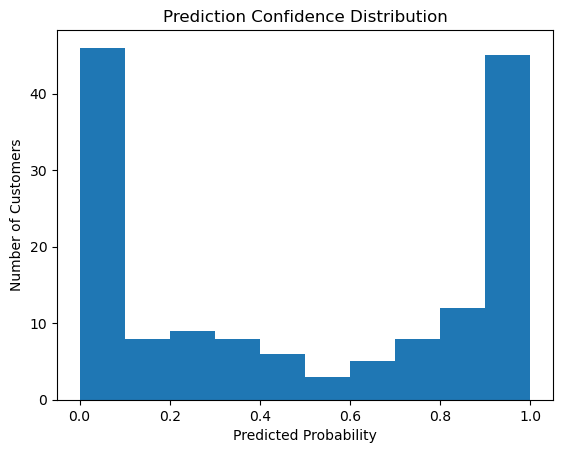

In [54]:
## Visualiztion

## Histogram
plt.hist(probabilities, bins=10)
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Customers")
plt.title("Prediction Confidence Distribution")
plt.show()


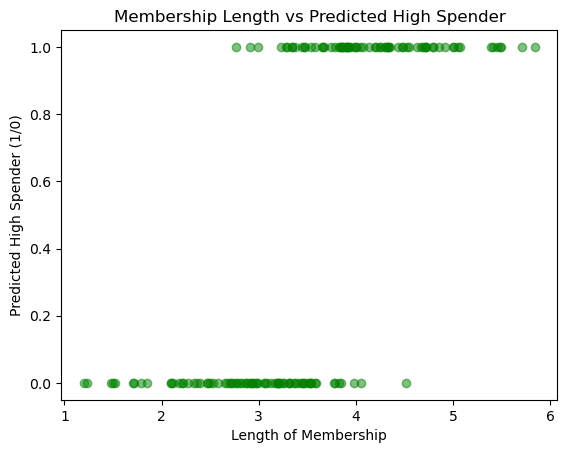

In [55]:
#Membership Length vs Prediction
plt.scatter(df["Length of Membership"].iloc[y_test.index], predicted_class, alpha=0.5, color="green")
plt.xlabel("Length of Membership")
plt.ylabel("Predicted High Spender (1/0)")
plt.title("Membership Length vs Predicted High Spender")
plt.show()


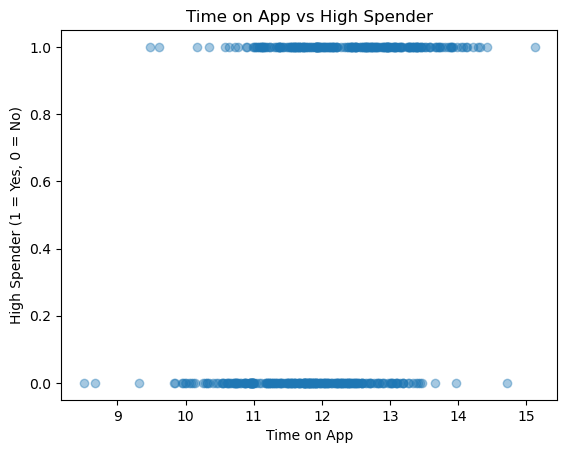

In [57]:
#“Does time spent on the mobile app affect customer spending?”
#Insight (Answer)
#Yes.
#Customers who spend more time on the app are more likely to be high spenders.

plt.scatter(df["Time on App"], df["High_Spender"], alpha=0.4)
plt.xlabel("Time on App")
plt.ylabel("High Spender (1 = Yes, 0 = No)")
plt.title("Time on App vs High Spender")
plt.show()


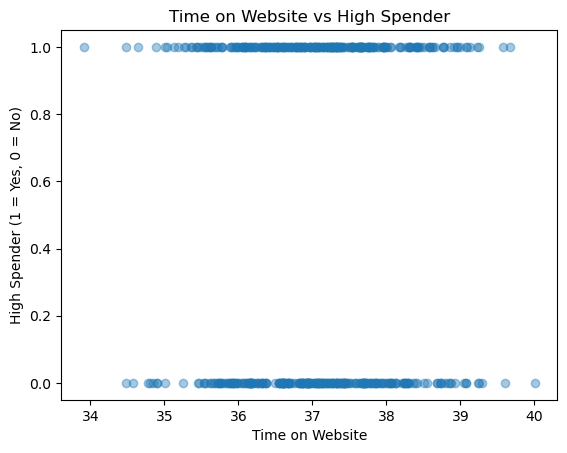

In [58]:
#“Does time spent on the website increase yearly spending?”
#Insight (Answer)
#Not strongly.
#Website time shows mixed behavior compared to app usage.

plt.scatter(df["Time on Website"], df["High_Spender"], alpha=0.4)
plt.xlabel("Time on Website")
plt.ylabel("High Spender (1 = Yes, 0 = No)")
plt.title("Time on Website vs High Spender")
plt.show()

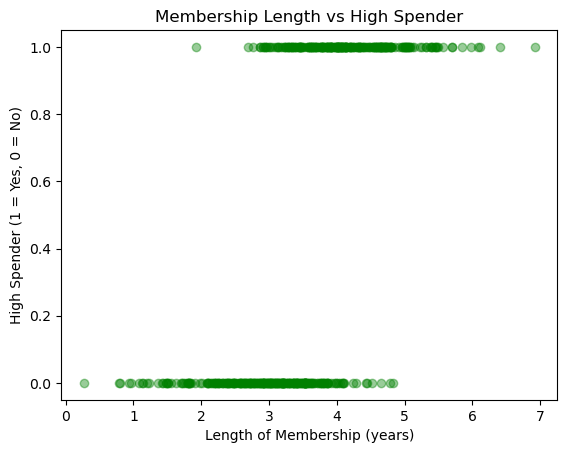

In [59]:
#“Does customer loyalty (membership length) matter?”
#Insight (Answer)
#Yes, strongly.
#Customers with longer membership are more likely to be high spenders.

plt.scatter(df["Length of Membership"], df["High_Spender"], alpha=0.4, color="green")
plt.xlabel("Length of Membership (years)")
plt.ylabel("High Spender (1 = Yes, 0 = No)")
plt.title("Membership Length vs High Spender")
plt.show()

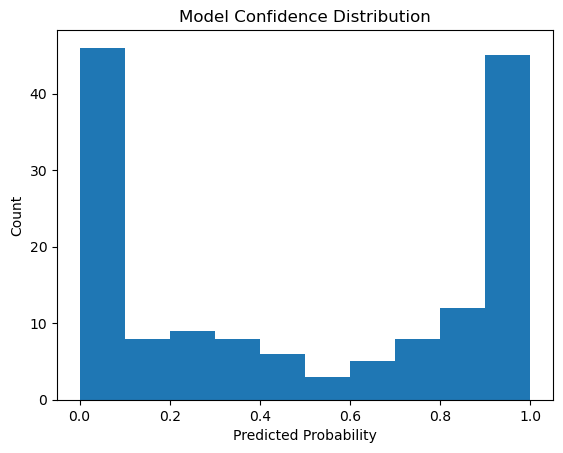

In [60]:
#“How confident is the model when predicting high spenders?”
#Insight (Answer)
#The model provides a probability score, showing confidence.
#•	High probability → confident high spender
#•	Low probability → confident low spender
plt.hist(probabilities, bins=10)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Model Confidence Distribution")
plt.show()

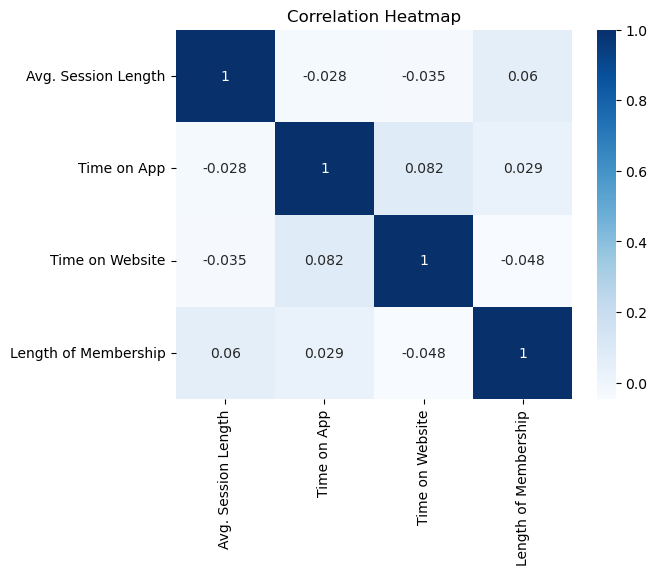

In [74]:
##Correlation HeatMap
import seaborn as sns

coef_df = (df[["Avg. Session Length",
        "Time on App",
        "Time on Website",
        "Length of Membership"]]).corr()

sns.heatmap(coef_df,annot=True,cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()